# Assignment 13.1 - Autoencoder (AE)

Please submit your solution of this notebook in the Whiteboard at the corresponding Assignment entry as .ipynb-file and as .pdf.

#### Please state both names of your group members here:
[Rashid Harvey and S M Shameem Ahmed Khan]

## Task 13.1.1: AE

* Implement a basic Autoencoder model and training loop that has a bottleneck, i.e., smaller latent dimension size as input/out dimension size. **(RESULT)**
* Train the Autoencoder on the MNIST dataset. **(RESULT)**
* Visualize some original and reconstructed images from the test set. **(RESULT)**
* Visualize the embeddings ofa subset (10 samples) of the test samples using `t-SNE`. You should use your trained encoder model to create those embeddings. **(RESULT)**

Training Autoencoder...
Epoch 1, Loss: 0.0477
Epoch 2, Loss: 0.0258
Epoch 3, Loss: 0.0205
Epoch 4, Loss: 0.0173
Epoch 5, Loss: 0.0155
Epoch 6, Loss: 0.0143
Epoch 7, Loss: 0.0134
Epoch 8, Loss: 0.0126
Epoch 9, Loss: 0.0118
Epoch 10, Loss: 0.0111

Visualizing reconstructions...


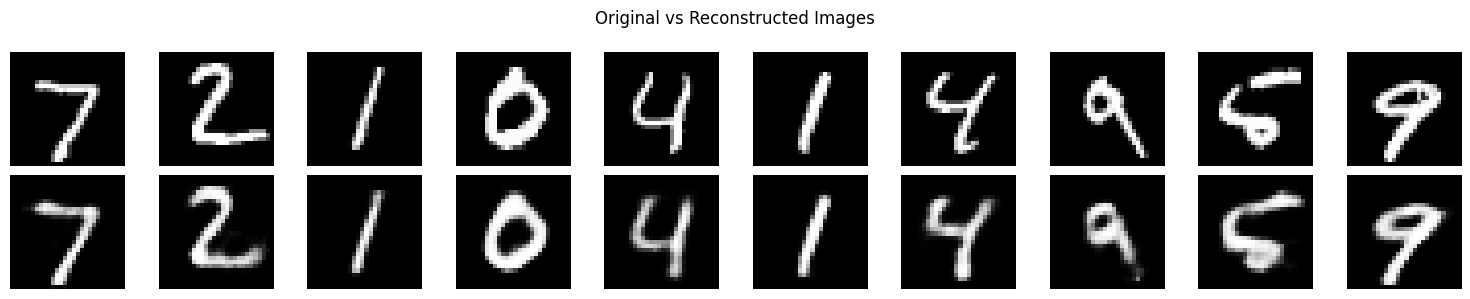

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

## Autoencoder Model
class Autoencoder(nn.Module):
    def __init__(self, input_dim=784, latent_dim=32):
        super(Autoencoder, self).__init__()
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, latent_dim),
        )
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, input_dim),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        x_flat = x.view(x.size(0), -1)
        latent = self.encoder(x_flat)
        reconstructed = self.decoder(latent)
        return reconstructed.view(x.size()), latent
    
    def encode(self, x):
        x_flat = x.view(x.size(0), -1)
        return self.encoder(x_flat)

## Load MNIST Data
transform = transforms.ToTensor()
train_data = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_data = datasets.MNIST('./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

## Initialize Model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = Autoencoder(input_dim=784, latent_dim=32).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

## Train Autoencoder
print("Training Autoencoder...")
model.train()
for epoch in range(10): 
    total_loss = 0
    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device)
        
        optimizer.zero_grad()
        reconstructed, _ = model(data)
        loss = criterion(reconstructed, data)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")

## Visualize Original vs Reconstructed Images
print("\nVisualizing reconstructions...")
model.eval()
with torch.no_grad():
    test_images, _ = next(iter(test_loader))
    test_images = test_images[:10].to(device)
    reconstructed, _ = model(test_images)

# Plot
fig, axes = plt.subplots(2, 10, figsize=(15, 3))
for i in range(10):
    axes[0, i].imshow(test_images[i].cpu().squeeze(), cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(reconstructed[i].cpu().squeeze(), cmap='gray')
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Original')
axes[1, 0].set_ylabel('Reconstructed')
plt.suptitle('Original vs Reconstructed Images')
plt.tight_layout()
plt.show()




Creating t-SNE visualization
Applying t-SNE to 10 samples per class...


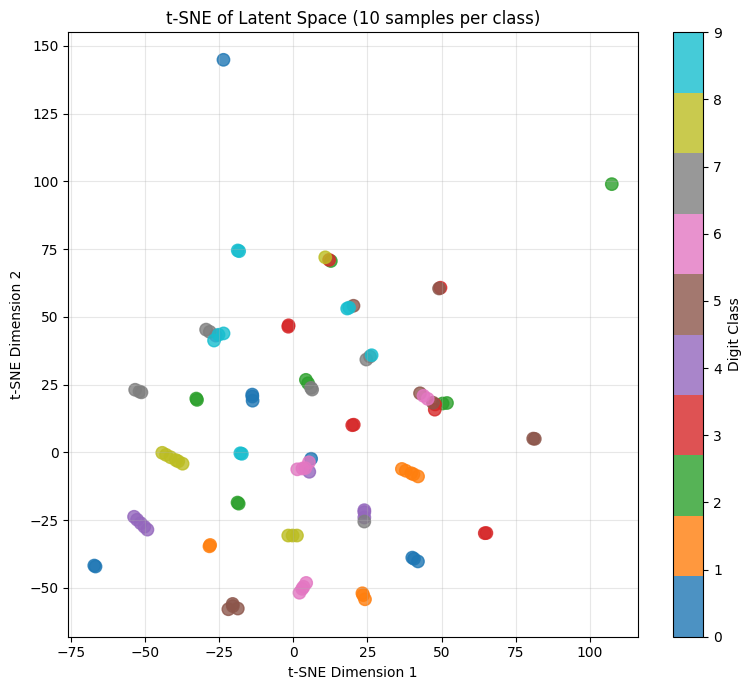

In [4]:

## t-SNE Visualization of 10 Samples
print("\nCreating t-SNE visualization")

def visualize_subset_tsne(model, test_dataset, samples_per_class=10):
    """
    Visualize t-SNE embeddings for 10 samples per class
    """
    model.eval()
    
    # Collect exactly 1 samples per class
    class_indices = {i: [] for i in range(10)}
    for idx in range(len(test_dataset)):
        _, label = test_dataset[idx]
        if len(class_indices[label]) < samples_per_class:
            class_indices[label].append(idx)
        
        # Check if we have enough samples for all classes
        if all(len(indices) >= samples_per_class for indices in class_indices.values()):
            break
    
    # Get the selected samples
    selected_indices = []
    selected_labels = []
    for label, indices in class_indices.items():
        selected_indices.extend(indices[:samples_per_class])
        selected_labels.extend([label] * samples_per_class)
    
    # Get the images and their latent representations
    images = []
    for idx in selected_indices:
        img, _ = test_dataset[idx]
        images.append(img)
    
    images = torch.stack(images).to(device)
    
    with torch.no_grad():
        latent_vectors = model.encode(images)
    
    latent_vectors = latent_vectors.cpu().numpy()
    selected_labels = np.array(selected_labels)
    
    # Apply t-SNE
    print(f"Applying t-SNE to {samples_per_class} samples per class...")
    tsne = TSNE(n_components=2, random_state=42, perplexity=1, max_iter=1000)
    latent_2d_subset = tsne.fit_transform(latent_vectors)
    
    # Create a more detailed visualization
    fig, ax1 = plt.subplots(1, 1, figsize=(8, 7))
    
    # Plot 1: Colored by class
    scatter1 = ax1.scatter(latent_2d_subset[:, 0], latent_2d_subset[:, 1], 
                          c=selected_labels, cmap='tab10', s=80, alpha=0.8)
    
    ax1.set_xlabel('t-SNE Dimension 1')
    ax1.set_ylabel('t-SNE Dimension 2')
    ax1.set_title(f't-SNE of Latent Space ({samples_per_class} samples per class)')
    ax1.grid(True, alpha=0.3)
    
    # Add colorbar
    cbar = fig.colorbar(scatter1, ax=ax1)
    cbar.set_label('Digit Class')
    
    plt.tight_layout()
    plt.show()
    
    return latent_2d_subset, selected_labels

# Visualize 1 samples per class
latent_2d_subset, subset_labels = visualize_subset_tsne(model, test_data)

## Task 13.1.2: VAE (BONUS)

* Implement a Variational Autoencoder model and training loop. Ideally you implement it close to the original using the reparametrization trick. **(RESULT)**
* Train the Variational Autoencoder on the MNIST dataset. **(RESULT)**
* Visualize some original and reconstructed images from the test set. **(RESULT)**
* Sample 10 synthetic images from the learned latent space by sampling from the prior distribution and passing the samples through the decoder. **(RESULT)**

Training VAE...
Epoch 1, Loss: 174.4295
Epoch 2, Loss: 129.5078
Epoch 3, Loss: 118.6089
Epoch 4, Loss: 114.0569
Epoch 5, Loss: 111.4348
Epoch 6, Loss: 109.5736
Epoch 7, Loss: 108.3790
Epoch 8, Loss: 107.4249
Epoch 9, Loss: 106.7254
Epoch 10, Loss: 106.1463
Epoch 11, Loss: 105.6217
Epoch 12, Loss: 105.1808
Epoch 13, Loss: 104.9084
Epoch 14, Loss: 104.6016
Epoch 15, Loss: 104.2850

Visualizing reconstructions...


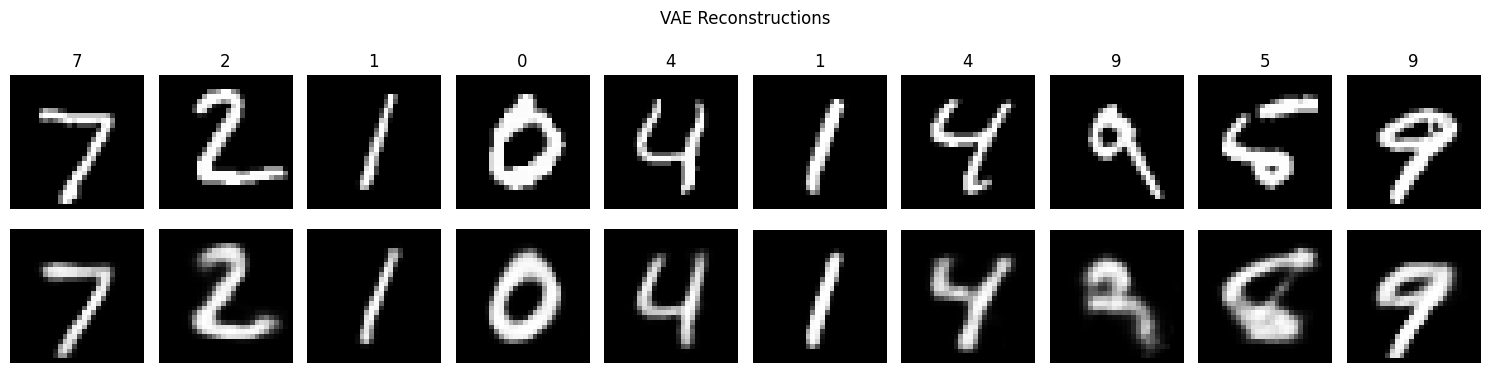


Generating synthetic images...


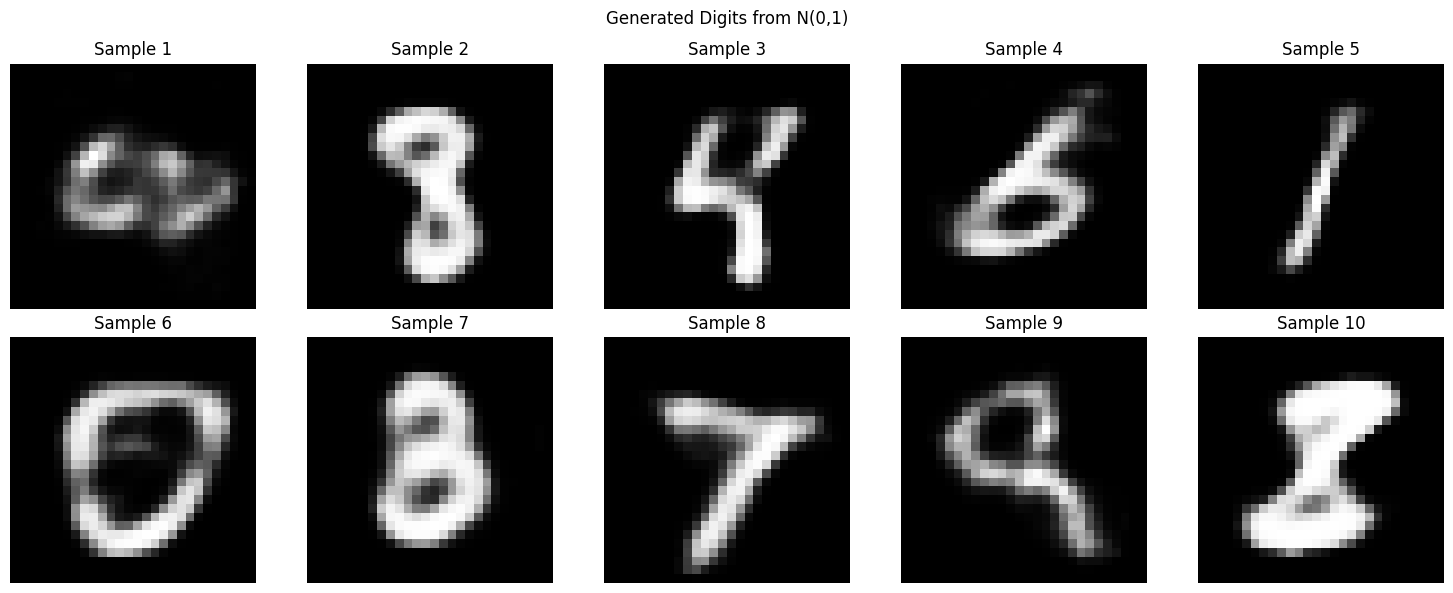


Done!


In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt

# VAE Model
class VAE(nn.Module):
    def __init__(self, input_dim=784, latent_dim=32):
        super(VAE, self).__init__()
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
        )
        
        self.fc_mu = nn.Linear(128, latent_dim)
        self.fc_logvar = nn.Linear(128, latent_dim)
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, input_dim),
            nn.Sigmoid()
        )
    
    def encode(self, x):
        x = x.view(x.size(0), -1)
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)
    
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def decode(self, z):
        return self.decoder(z)
    
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z).view(x.size()), mu, logvar

# VAE Loss
def vae_loss(reconstructed, original, mu, logvar):
    BCE = F.binary_cross_entropy(reconstructed.view(-1, 784), original.view(-1, 784), reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD

# Load data
transform = transforms.ToTensor()
train_data = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_data = datasets.MNIST('./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

# Setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = VAE(input_dim=784, latent_dim=32).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Train VAE
print("Training VAE...")
model.train()
for epoch in range(15):
    total_loss = 0
    for data, _ in train_loader:
        data = data.to(device)
        
        optimizer.zero_grad()
        reconstructed, mu, logvar = model(data)
        loss = vae_loss(reconstructed, data, mu, logvar)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader.dataset):.4f}")

# Visualize reconstructions
print("\nVisualizing reconstructions...")
model.eval()
with torch.no_grad():
    test_images, labels = next(iter(test_loader))
    test_images = test_images[:10].to(device)
    reconstructed, _, _ = model(test_images)

fig, axes = plt.subplots(2, 10, figsize=(15, 4))
for i in range(10):
    axes[0, i].imshow(test_images[i].cpu().squeeze(), cmap='gray')
    axes[0, i].set_title(f'{labels[i]}')
    axes[0, i].axis('off')
    axes[1, i].imshow(reconstructed[i].cpu().squeeze(), cmap='gray')
    axes[1, i].axis('off')
axes[0, 0].set_ylabel('Original')
axes[1, 0].set_ylabel('Reconstructed')
plt.suptitle('VAE Reconstructions')
plt.tight_layout()
plt.show()

# Generate synthetic images
print("\nGenerating synthetic images...")
model.eval()
with torch.no_grad():
    z = torch.randn(10, 32).to(device)  # Sample from N(0,1)
    generated = model.decode(z)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i in range(10):
    ax = axes[i // 5, i % 5]
    ax.imshow(generated[i].cpu().view(28, 28), cmap='gray')
    ax.set_title(f'Sample {i+1}')
    ax.axis('off')
plt.suptitle('Generated Digits from N(0,1)')
plt.tight_layout()
plt.show()

## Congratz, you made it! :)